Xg boost Model 



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


### 2. Data Cleaning & Feature Engineering

In [3]:
# Drop duplicates and clip unrealistic physical activity hrs
df = df.drop_duplicates().copy()
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0) # -ve hrs value to 0

# Group top 10 countries, group remaining as 'Other'
top_countries = df['Country'].value_counts().index[:10].tolist()
df['Grouped_country'] = df['Country'].where(df['Country'].isin(top_countries), other='Other')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


### 3. Feature Selection & Train-Test Split

In [4]:
skewed_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks",
                      "Physical_Activity_Hours", "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]

feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

### 4. Build Preprocessing Pipelines

In [5]:
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale', StandardScaler())
])

plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    ('encode', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']], handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_pipeline = Pipeline(steps=[
    ('encode', OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("Skewed_Pipeline", skew_pipeline, skewed_col),
    ("Plain_Numeric", plain_numeric_pipeline, other_numeric_cols),
    ('Ordinal', ordinal_pipeline, ordinal_col),
    ('Nominal', nominal_pipeline, normal_col)
])

### 5. XGBoost Regressor (Baseline Model)

In [6]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgboost', XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)

xgb_preds       = xgb_pipeline.predict(X_test)
xgb_preds_train = xgb_pipeline.predict(X_train)

xgb_r2_testing  = r2_score(y_test, xgb_preds)
xgb_r2_training = r2_score(y_train, xgb_preds_train)
xgb_mae         = mean_absolute_error(y_test, xgb_preds)
xgb_mse         = mean_squared_error(y_test, xgb_preds)
xgb_rmse        = np.sqrt(xgb_mse)
xgb_rmse_train  = np.sqrt(mean_squared_error(y_train, xgb_preds_train))

print(f"Baseline XGBoost Training R2  : {xgb_r2_training:.4f}")
print(f"Baseline XGBoost Testing R2   : {xgb_r2_testing:.4f}")
print(f"Baseline XGBoost Training RMSE: {xgb_rmse_train:.4f}")
print(f"Baseline XGBoost Testing RMSE : {xgb_rmse:.4f}")
print(f"Baseline XGBoost Testing MAE  : {xgb_mae:.4f}")

Baseline XGBoost Training R2  : 0.9136
Baseline XGBoost Testing R2   : 0.8491
Baseline XGBoost Training RMSE: 0.3696
Baseline XGBoost Testing RMSE : 0.5147
Baseline XGBoost Testing MAE  : 0.3977


### 6. Hyperparameter Tuning with RandomizedSearchCV

In [7]:
param_grid = {
    'xgboost__n_estimators': [100, 200, 300, 500],
    'xgboost__learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'xgboost__max_depth': [3, 4, 6, 8],
    'xgboost__subsample': [0.6, 0.8, 1.0],
    'xgboost__colsample_bytree': [0.6, 0.8, 1.0],
    'xgboost__reg_alpha': [0, 0.1, 1.0],
    'xgboost__reg_lambda': [0.5, 1.0, 2.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgboost__colsample_bytree': [0.6, 0.8, ...], 'xgboost__learning_rate': [0.01, 0.03, ...], 'xgboost__max_depth': [3, 4, ...], 'xgboost__n_estimators': [100, 200, ...], ...}"
,n_iter,30
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### 7. Best Parameters

In [8]:
print("Best Hyperparameters for XGBoost:")
print(random_search.best_params_)

Best Hyperparameters for XGBoost:
{'xgboost__subsample': 0.6, 'xgboost__reg_lambda': 2.0, 'xgboost__reg_alpha': 0.1, 'xgboost__n_estimators': 500, 'xgboost__max_depth': 8, 'xgboost__learning_rate': 0.05, 'xgboost__colsample_bytree': 0.8}


### 8. Evaluate Tuned XGBoost Model

In [9]:
xgb_best_pipeline = random_search.best_estimator_

xgb_tuned_preds          = xgb_best_pipeline.predict(X_test)
xgb_tuned_preds_training = xgb_best_pipeline.predict(X_train)

xgb_tuned_r2_test       = r2_score(y_test, xgb_tuned_preds)
xgb_tuned_r2_train      = r2_score(y_train, xgb_tuned_preds_training)
xgb_tuned_mae           = mean_absolute_error(y_test, xgb_tuned_preds)
xgb_tuned_mse           = mean_squared_error(y_test, xgb_tuned_preds)
xgb_tuned_rmse          = np.sqrt(xgb_tuned_mse)
xgb_tuned_rmse_train    = np.sqrt(mean_squared_error(y_train, xgb_tuned_preds_training))

print(f"Tuned XGBoost Training R2  : {xgb_tuned_r2_train:.4f}")
print(f"Tuned XGBoost Testing R2   : {xgb_tuned_r2_test:.4f}")
print(f"Tuned XGBoost Training RMSE: {xgb_tuned_rmse_train:.4f}")
print(f"Tuned XGBoost Testing RMSE : {xgb_tuned_rmse:.4f}")
print(f"Tuned XGBoost Testing MAE  : {xgb_tuned_mae:.4f}")

Tuned XGBoost Training R2  : 0.9944
Tuned XGBoost Testing R2   : 0.8946
Tuned XGBoost Training RMSE: 0.0939
Tuned XGBoost Testing RMSE : 0.4303
Tuned XGBoost Testing MAE  : 0.3195


### 9. Comparison: Baseline vs Tuned XGBoost

In [10]:
results = pd.DataFrame({
    'Model': ['XGBoost (Baseline)', 'XGBoost (Tuned)'],
    'Training R2': [xgb_r2_training, xgb_tuned_r2_train],
    'Testing R2': [xgb_r2_testing, xgb_tuned_r2_test],
    'Training RMSE': [xgb_rmse_train, xgb_tuned_rmse_train],
    'Testing RMSE': [xgb_rmse, xgb_tuned_rmse],
    'Testing MAE': [xgb_mae, xgb_tuned_mae]
})

results

,Model,Training R2,Testing R2,Training RMSE,Testing RMSE,Testing MAE
0,XGBoost (Baseline),0.913597,0.849147,0.369564,0.514737,0.397724
1,XGBoost (Tuned),0.994418,0.894557,0.093930,0.430346,0.319520


### 10. Feature Importance Visualization

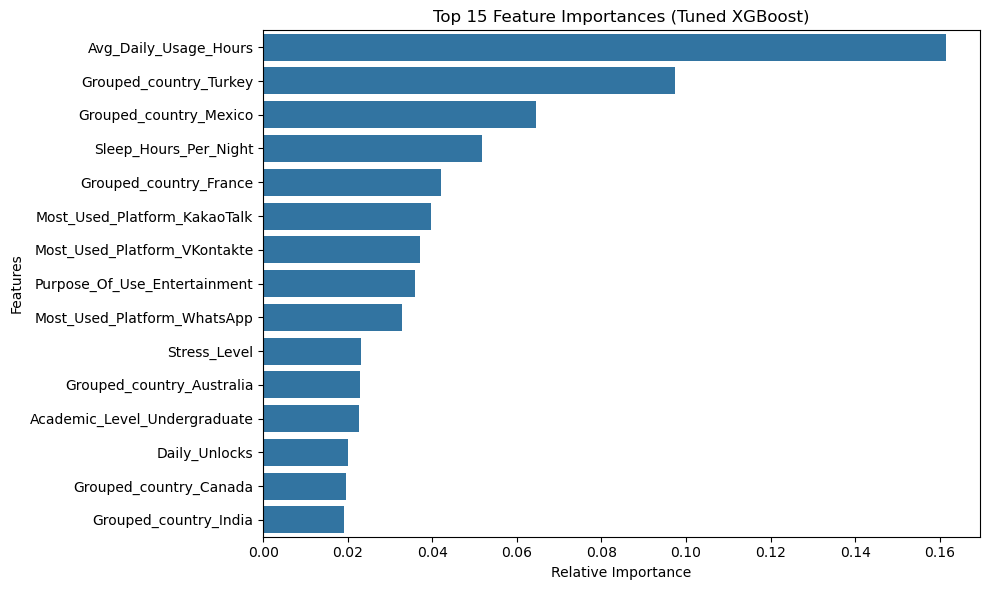

In [11]:
# Extract transformed feature names and clean prefixes
raw_feature_names = xgb_best_pipeline.named_steps['preprocessor'].get_feature_names_out()
clean_feature_names = [col.split('__')[-1] for col in raw_feature_names]
importances = xgb_best_pipeline.named_steps['xgboost'].feature_importances_

feat_imp = pd.Series(importances, index=clean_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 15 Feature Importances (Tuned XGBoost)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()